In [1]:
%matplotlib inline
import glob
import os
import gc
from secsy import cubedsphere as cs
from secsy import CSplot
from secsy import get_SECS_J_G_matrices, get_SECS_B_G_matrices
import lompe
import apexpy
import pyamps
import dipole
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import polplot
from pyamps.plot_utils import Polarsubplot
from pyamps import AMPS
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
from my_utils import load_omni

from IPython.display import clear_output


In [ ]:
RE = 6371.2e3
RI = RE + 110e3

theta0 = 0.25 # for j_G matrix singularity limit

Epoch = 2025 # REMEMBER TO CHANGE TO FIT DATA

# make cubed sphere projection and grid
location = (-40,71)
orientation = 0
#L, W, Lres, Wres = 4500e3,3500e3,30,25
L, W, Lres, Wres = 4500e3,3500e3,100.0e3,100.0e3


projection = cs.CSprojection(location, orientation)
grid = cs.CSgrid(projection, L, W, Lres, Wres, R = RI, wshift=1.0)

shp = grid.shape

# make lompe model, used to compute gradient matrices in magnetic east/west (conductances don't matter for us)
model = lompe.Emodel(grid, Hall_Pedersen_conductance = (0,0), epoch=Epoch, ew_regularization_limit=(70,89))

# Define meridian
mlon_m = 50
meridian_lat_qd = np.arange(60, 86+0.2, 0.2)
meridian_lon_qd = np.ones(len(meridian_lat_qd))*mlon_m

apex_obj = apexpy.Apex(date=datetime(2025, 2, 12), refh=110)
meridian_lat_geo, meridian_lon_geo = apex_obj.convert(meridian_lat_qd, meridian_lon_qd, 'qd', 'geo')

In [4]:
# Matrices to get predictions of B on meridian
GeB_m, GnB_m, GuB_m = get_SECS_B_G_matrices(meridian_lat_geo, meridian_lon_geo, RE, grid.lat.flatten(), grid.lon.flatten())
# Matrices to get predictions of j on meridian
Gej_m, Gnj_m = get_SECS_J_G_matrices(meridian_lat_geo, meridian_lon_geo, grid.lat.flatten(), grid.lon.flatten(), singularity_limit = theta0 * np.pi / 180 * RI)


In [5]:
accepted_times = np.load('concurrent_times_supermag.npy', allow_pickle=True)

# Load all CSVs from folder

all_dfs = []
for folder in ['2023','2024','2025']:
    csv_files = glob.glob(os.path.join('supermag_downloads/yearly_BASELINE', folder, "*.csv"))
    if csv_files:
        all_dfs.append(pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True))

df = pd.concat(all_dfs, ignore_index=True)

del all_dfs
gc.collect()

df['time'] = pd.to_datetime(df['time'])

# Filter to accepted times only
df = df[df["time"].isin(accepted_times)]

# Sort by time then iaga
df = df.sort_values(by=["time", "iaga"]).reset_index(drop=True)

In [6]:
## REMOVE TIMES WHERE REMAINING NANS ARE
na_mask = df['dbn_geo'].isna()
times_na = df['time'][na_mask]
df_mag = df[~df['time'].isin(times_na)]
print('Shape with no nans:',df_mag.shape)

Shape with no nans: (3657300, 6)


In [7]:
df_mag = df_mag.rename(columns={'time': 'Date_UTC', 'iaga': 'IAGA'})

In [7]:
df_mag.isna().sum()

Date_UTC    0
ext         0
IAGA        0
dbn_geo     0
dbe_geo     0
dbz_geo     0
dtype: int64

In [7]:
na_mask = df_mag['dbn_geo'].isna()
df_mag_na = df_mag[na_mask]
for stat in df_mag_na['IAGA'].unique():
    df_temp = df_mag_na[df_mag_na['IAGA']==stat]
    print(df_temp.shape[0])


df_mag_na['IAGA'].unique()

<StringArray>
[]
Length: 0, dtype: str

In [8]:
df_mag

,Date_UTC,ext,IAGA,dbn_geo,dbe_geo,dbz_geo
0,2023-01-02 00:00:00,60.0,BJN,-87.573467,28.435051,70.501725
1,2023-01-02 00:00:00,60.0,DMH,-6.852860,-9.026238,67.700384
2,2023-01-02 00:00:00,60.0,GDH,-80.203076,8.020734,-34.897839
3,2023-01-02 00:00:00,60.0,HOP,-67.794780,10.762414,119.697826
4,2023-01-02 00:00:00,60.0,HOV,-17.931120,12.596622,12.382981
...,...,...,...,...,...,...
3741455,2025-01-29 03:56:00,60.0,RES,4.500614,-1.105482,-6.764334
3741456,2025-01-29 03:56:00,60.0,SKT,-2.935053,3.141983,15.932440
3741457,2025-01-29 03:56:00,60.0,STF,4.769580,8.467703,18.025840
3741458,2025-01-29 03:56:00,60.0,SUM,2.321143,10.438069,6.578222


In [8]:
df_omni = []
mask_omni = []
for year in [2023,2024,2025]:
    df_omni_temp, mask_omni_temp = load_omni(f'omni_files/omni_{year}.lst', times=df_mag['Date_UTC'].unique(), hourly=False)
    df_omni.append(df_omni_temp)
    mask_omni.append(mask_omni_temp)

df_omni = pd.concat(df_omni, ignore_index=False)
mask_omni = pd.concat(mask_omni, ignore_index=False)

In [9]:
times_filter = mask_omni.index[mask_omni]

df_omni_filtered = df_omni[mask_omni]

df_mag_filtered = df_mag[df_mag['Date_UTC'].isin(times_filter)]
df_mag_filtered['dbu_geo'] = -df_mag_filtered['dbz_geo']

In [10]:
# number of days in final data used for validation
df_omni_filtered.shape[0]/60/24

61.293749999999996

In [11]:
stations = df_mag_filtered['IAGA'].unique()
times = df_mag_filtered['Date_UTC'].unique()

# Pivot the entire DataFrame at once
# Rows = Stations, Columns = Time, Values = The 3 components
pivoted = df_mag_filtered.pivot(index='IAGA', columns='Date_UTC', 
                                values=['dbe_geo', 'dbn_geo', 'dbu_geo'])

# Ensure the rows (stations) and columns (time) stay in original order
pivoted = pivoted.reindex(index=stations, columns=times, level=1)

# Extract the three (20 x T) blocks and stack them vertically
# pivoted['column_name'] returns a (20, T) array
d = np.vstack([
    pivoted['dbe_geo'].values, 
    pivoted['dbn_geo'].values, 
    pivoted['dbu_geo'].values
])

# convert to nT
d = d * 1e-9

In [12]:
# Path to your CSV file
file_path = "SuperMAG_stations.csv"

# Read CSV
df = pd.read_csv(file_path)

# Make sure column names match your file exactly
# Adjust these if necessary after checking df.columns
iaga_column = "IAGA"
lat_column = "GLAT"
lon_column = "GLON"

# Filter stations based on IAGA list (and sort by station name so it matches df_mag)
filtered_df = df[df[iaga_column].isin(stations)].sort_values('IAGA')

# Extract latitude and longitude vectors
lat_mag = filtered_df[lat_column].to_numpy()
lon_mag = filtered_df[lon_column].to_numpy()

In [14]:
#n_mag = df_mag['IAGA'].unique().size
n_mag = df_mag_filtered['IAGA'].unique().size
#n_t = df_mag['Date_UTC'].unique().size
n_t = df_mag_filtered['Date_UTC'].unique().size

i = 0

#lon_mag, lat_mag = (df_mag_filtered['GEOLON'].values[0:n_mag]+180)%360-180, df_mag_filtered['GEOLAT'].values[0:n_mag]

GeB_mag, GnB_mag, GuB_mag = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon)
  
depth = 400e3 # depth where Br = 0 [m]
GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon, induction_nullification_radius = RE - depth)
#GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon)

# G matrix for the mirror current method:
G_mirror = np.vstack((GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror)) # shape: (3*N, grid.size)

# Approach number 2: East-west minimization
Le, Ln, LTLe, LTLn = model.compute_L_matrices(grid) # get matrices that calculate MAGNETIC eastward and northward components of gradient
GTG_mirror, GTd_mirror = G_mirror.T.dot(G_mirror), G_mirror.T.dot(d) # we multiply the set of equations by G_mirror transpose
LTL = LTLe
T0, T1 = 8e-24, 1e-21 # regularization parameters from Walker
R = T0 * np.eye(grid.size) + T1 * LTL # regularization matrix
I_mirror = np.linalg.lstsq(GTG_mirror + R, GTd_mirror, rcond = 0)[0]

# Model predictions at meridian
Bu_m = GuB_m.dot(I_mirror)
je_m, jn_m = Gej_m.dot(I_mirror), Gnj_m.dot(I_mirror)

# GETTING MLT FOR EACH TIME/MERIDAN:
mlt = pyamps.mlon_to_mlt(mlon_m, times, Epoch)


In [15]:
df_b = pd.DataFrame(columns=['time','MLT','clock_angle','Br','je','jn'])
df_b['time'] = times_filter
df_b.set_index('time', inplace=True)
df_b = df_b.sort_index()

df_b['MLT'] = mlt
df_b['clock_angle'] = df_omni_filtered['clock_angle'].values
df_b['Br'] = [Bu_m[:, i] for i in range(Bu_m.shape[1])]
df_b['je'] = [je_m[:, i] for i in range(je_m.shape[1])]
df_b['jn'] = [jn_m[:, i] for i in range(jn_m.shape[1])]

df_b.head()

,MLT,clock_angle,Br,je,jn
time,,,,,
2023-01-02 00:00:00,21.497368,119.100219,"[-2.6341405218354967e-08, -2.6996034092604494e...","[-0.017819307394540112, -0.019377338146322122,...","[-0.001471439615161464, -0.0018098519835384385..."
2023-01-02 00:01:00,21.514090,119.122725,"[-2.6223585277749658e-08, -2.6889967559636423e...","[-0.016178282695056223, -0.017798685754064, -0...","[-0.0034025477051010675, -0.003793680558721171..."
2023-01-02 00:02:00,21.530818,119.607922,"[-2.5961848803782733e-08, -2.6603489363015697e...","[-0.014692181779907826, -0.01627877774008223, ...","[-0.004323786235457341, -0.00473802300242585, ..."
2023-01-02 00:03:00,21.547552,119.275254,"[-2.297823907483952e-08, -2.3536444007926302e-...","[-0.011075235095491227, -0.012456794718911576,...","[-0.004037066205008385, -0.004406887940233831,..."
2023-01-02 00:04:00,21.564292,119.573104,"[-1.9607657491988446e-08, -2.0090221596167994e...","[-0.007484831920967579, -0.008667961260335047,...","[-0.004354061268578359, -0.004690320382628999,..."


**PRINT/LOAD df_b HERE**

In [4]:
#df_b.to_pickle("data_frames/df_b_supermag.pkl")
df_b = pd.read_pickle("data_frames/df_b_supermag.pkl")

In [7]:
df_omni = []
mask_omni = []
for year in [2023,2024,2025]:
    df_omni_temp, mask_omni_temp = load_omni(f'omni_files/omni_{year}.lst', times=df_b.index, hourly=False)
    df_omni.append(df_omni_temp)
    mask_omni.append(mask_omni_temp)

df_omni = pd.concat(df_omni, ignore_index=False)
mask_omni = pd.concat(mask_omni, ignore_index=False)

times_filter = mask_omni.index[mask_omni]
df_omni_filtered = df_omni[mask_omni]

In [12]:
df_omni_filtered.shape[0]/60/24

61.293749999999996

**PRINT/LOAD OVER**

In [16]:
### Grouping by IMF clock angle and then binning by MLT 

# Define MLT bins (0.5 hour steps)
mlt_bins = np.arange(0, 24 + 0.5, 0.5)

# Create the binning column
# 'labels' uses the start of the bin (e.g., 21.0 for the 21.0-21.5 bin)
df_b['MLT_bin'] = pd.cut(df_b['MLT'], bins=mlt_bins, labels=mlt_bins[:-1], include_lowest=True)

# Define the specific vector columns to average
vector_cols = ['Br', 'je', 'jn']

# Define a helper to average a series of vectors
def average_vector_series(series):
    # Stack the list/arrays into a 2D matrix and mean along rows
    return np.mean(np.stack(series.values), axis=0).tolist()

# Group meridian results by IMF clock-angle
df_1 = df_b[(df_b['clock_angle'] > (-135-22.5)) & (df_b['clock_angle'] < (-135+22.5))] # -135deg +- 22.5deg
df_2 = df_b[(df_b['clock_angle'] > (180-22.5)) | (df_b['clock_angle'] < (-180+22.5))] # 180deg +- 22.5deg
df_3 = df_b[(df_b['clock_angle'] > (135-22.5)) & (df_b['clock_angle'] < (135+22.5))] # 135deg +- 22.5deg

# Group by bin and apply the function only to target columns
# observed=True skips bins that have no data points
mlt_vectors_1 = df_1.groupby('MLT_bin', observed=True)[vector_cols].agg(average_vector_series)
mlt_vectors_2 = df_2.groupby('MLT_bin', observed=True)[vector_cols].agg(average_vector_series)
mlt_vectors_3 = df_3.groupby('MLT_bin', observed=True)[vector_cols].agg(average_vector_series)

# Reset index to make MLT_bin a normal column again
mlt_vectors_1 = mlt_vectors_1.reset_index()
mlt_vectors_2 = mlt_vectors_2.reset_index()
mlt_vectors_3 = mlt_vectors_3.reset_index()

In [17]:
# Group omni data by IMF clock-angle
omni_1 = df_omni_filtered[(df_omni_filtered['clock_angle'] > (-135-22.5)) & (df_omni_filtered['clock_angle'] < (-135+22.5))] # -135deg +- 22.5deg
omni_2 = df_omni_filtered[(df_omni_filtered['clock_angle'] > (180-22.5)) | (df_omni_filtered['clock_angle'] < (-180+22.5))] # 180deg +- 22.5deg
omni_3 = df_omni_filtered[(df_omni_filtered['clock_angle'] > (135-22.5)) & (df_omni_filtered['clock_angle'] < (135+22.5))] # 135deg +- 22.5deg


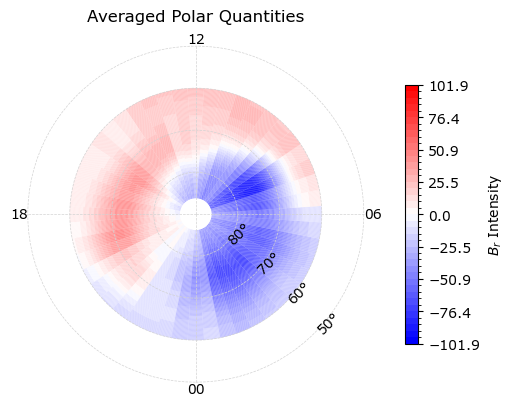

In [15]:
# Flatten for plot_utils
# We need to create a matching (mlat, mlt) coordinate for every value in the vectors
mlts_plot = []
mlats_plot = []
br_plot = []
je_plot = []
jn_plot = []

for _, row in mlt_vectors_1.iterrows():
    # Use the center of the 0.5h bin
    mlt_center = float(row['MLT_bin']) + 0.25 
    
    # Repeat the MLT and Latitudes for the length of the vector (141)
    mlts_plot.extend([mlt_center] * len(meridian_lat_qd))
    mlats_plot.extend(meridian_lat_qd)
    
    # Append the actual data
    br_plot.extend(row['Br'])
    je_plot.extend(row['je'])
    jn_plot.extend(row['jn'])

# Convert to numpy arrays
mlts_plot = np.array(mlts_plot)
mlats_plot = np.array(mlats_plot)
br_plot = np.array(br_plot) *1e9
je_plot = np.array(je_plot)
jn_plot = np.array(jn_plot)

lat_res = np.diff(np.sort(np.unique(mlats_plot)))[0]
mlt_res = np.diff(np.sort(np.unique(mlts_plot)))[0]

# Setup the Polarplot
fig, ax = plt.subplots()
pax = polplot.Polarplot(ax)

absmax = np.max(np.abs(br_plot))
levels = np.linspace(-absmax, absmax, 41)
norm = mcolors.BoundaryNorm(levels, plt.cm.bwr.N)

pax.writeLATlabels(color='black',backgroundcolor=(0, 0, 0, 0))
pax.writeLTlabels()
im = pax.filled_cells(mlats_plot, mlts_plot, lat_res, mlt_res, br_plot, 
                       cmap=plt.cm.bwr, levels=levels)

# Manually create a ScalarMappable for the colorbar
sm = cm.ScalarMappable(cmap=plt.cm.bwr, norm=norm)
sm.set_array([])

plt.colorbar(sm, ax=ax, label='$B_r$ Intensity', shrink=0.7)
plt.title("Averaged Polar Quantities")
plt.show()

In [42]:
wind_median = df_omni_filtered['plasma_speed'].median()
By_median = df_omni_filtered['by'].median()
Bz_median = df_omni_filtered['bz'].median()
tilt_median = df_omni_filtered['tilts'].median()

m = AMPS(wind_median, # Solar wind velocity in km/s
              By_median, # IMF By (GSM) in nT
              Bz_median, # IMF Bz (GSM) in nT,
              tilt_median, # dipole tilt angle in degrees
              100) # F107_index
# make summary plot:
mlat_amps, mlt_amps = m.scalargrid
Bu_amps = m.get_ground_Buqd()

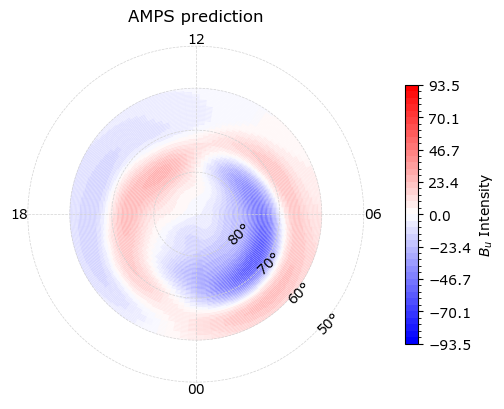

In [43]:
fig, ax = plt.subplots()
pax = polplot.Polarplot(ax)

Bu_plot = Bu_amps.copy()  # protect original from modification

absmax = np.max(np.abs(Bu_plot))
levels = np.linspace(-absmax, absmax, 41)
norm = mcolors.BoundaryNorm(levels, plt.cm.bwr.N)

pax.writeLATlabels(color='black',backgroundcolor=(0, 0, 0, 0))
pax.writeLTlabels()
im = pax.filled_cells(mlat_amps, mlt_amps, lat_res, mlt_res, Bu_plot, 
                       cmap=plt.cm.bwr, levels=levels)

sm = cm.ScalarMappable(cmap=plt.cm.bwr, norm=norm)
sm.set_array([])

plt.colorbar(sm, ax=ax, label='$B_u$ Intensity', shrink=0.7)
plt.title("AMPS prediction")
plt.show()

**MAKING THE REAL FINAL PLOT**

In [18]:
def extract_plot_arrays(mlt_vectors, meridian_lat_qd):
    mlts_plot, mlats_plot, br_plot, je_plot, jn_plot = [], [], [], [], []

    for _, row in mlt_vectors.iterrows():
        mlt_center = float(row['MLT_bin']) + 0.25
        mlts_plot.extend([mlt_center] * len(meridian_lat_qd))
        mlats_plot.extend(meridian_lat_qd)
        br_plot.extend(row['Br'])
        je_plot.extend(row['je'])
        jn_plot.extend(row['jn'])

    return (
        np.array(mlts_plot),
        np.array(mlats_plot),
        np.array(br_plot) * 1e9,
        np.array(je_plot),
        np.array(jn_plot),
    )

# --- Helper: compute AMPS prediction arrays from omni DataFrame ---
def extract_amps_arrays(omni):
    wind_median = omni['plasma_speed'].median()
    By_median   = omni['by'].median()
    Bz_median   = omni['bz'].median()
    tilt_median = omni['tilts'].median()

    m = AMPS(wind_median, By_median, Bz_median, tilt_median, 150)
    mlat_amps, mlt_amps = m.scalargrid
    Bu_amps = m.get_ground_Buqd()
    je_amps, jn_amps = m.get_divergence_free_current(mlat_amps, mlt_amps) # NB: uses mA/m as unit

    return mlat_amps, mlt_amps, Bu_amps.copy(), je_amps, jn_amps

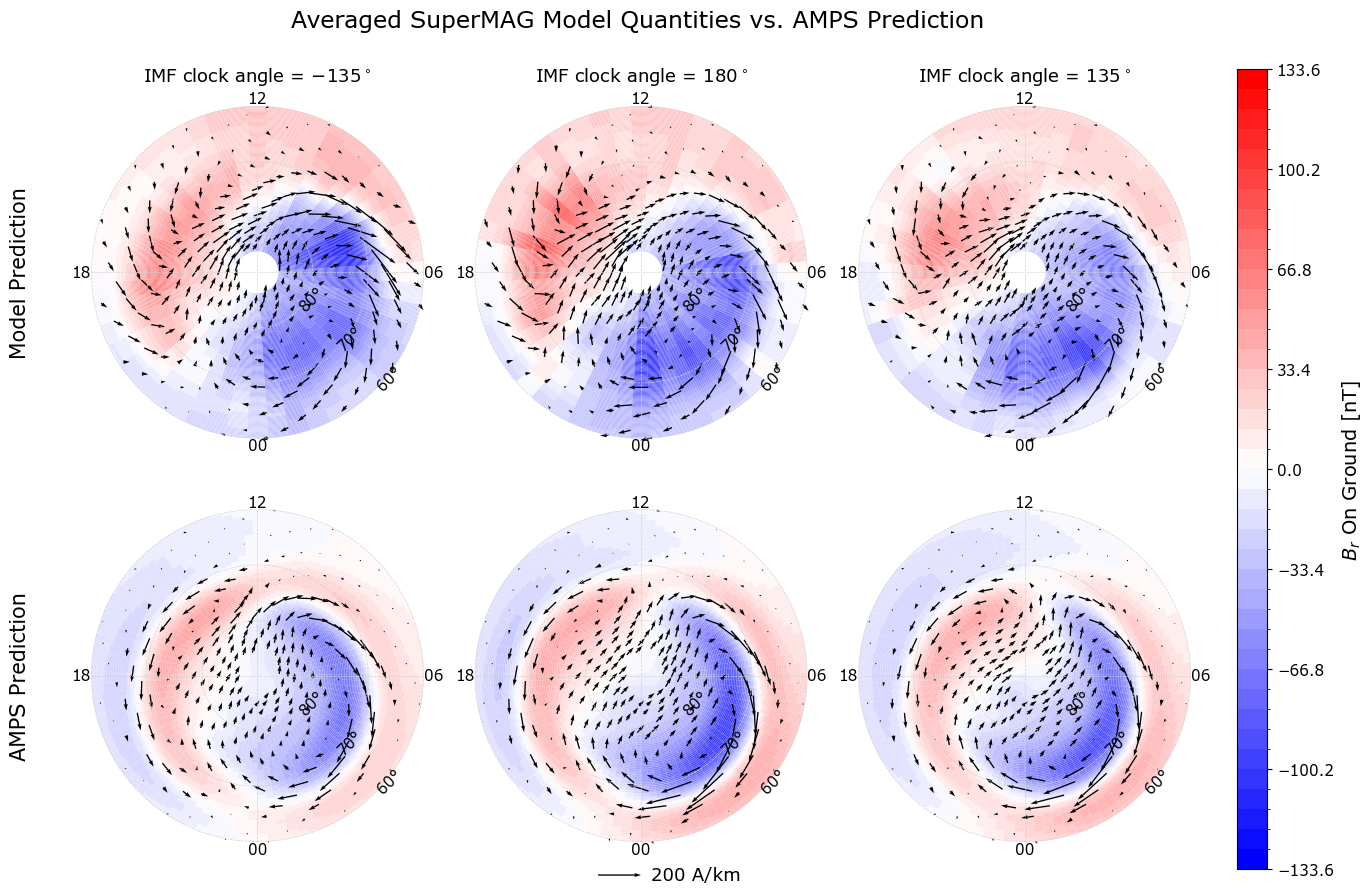

In [ ]:
# ----------------------------------------------------------------
# Prepare all data
# ----------------------------------------------------------------
mlt_datasets  = [mlt_vectors_1, mlt_vectors_2, mlt_vectors_3]
omni_datasets = [omni_1,        omni_2,        omni_3       ]
col_titles    = ["IMF clock angle = $-135^\circ$", "IMF clock angle = $180^\circ$", "IMF clock angle = $135^\circ$"]

row1_arrays = [extract_plot_arrays(ds, meridian_lat_qd) for ds in mlt_datasets]
row2_arrays = [extract_amps_arrays(omni) for omni in omni_datasets]

absmax_global = max(
    max(np.max(np.abs(arr[2])) for arr in row1_arrays),
    max(np.max(np.abs(arr[2])) for arr in row2_arrays),
)
levels = np.linspace(-absmax_global, absmax_global, 41)
norm   = mcolors.BoundaryNorm(levels, plt.cm.bwr.N)

# ----------------------------------------------------------------
# Build figure: 2 rows x 3 cols, with a colorbar column on the right
# ----------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.subplots_adjust(right=0.88, wspace=0.05, hspace=0.1)

# --- Row 1: measured Br ---
for col, (ax, (mlts, mlats, br, je, jn)) in enumerate(zip(axes[0], row1_arrays)):
    lat_res = np.diff(np.sort(np.unique(mlats)))[0]
    mlt_res = np.diff(np.sort(np.unique(mlts)))[0]

    pax = polplot.Polarplot(ax, minlat=60)
    pax.writeLATlabels(color='black', fontsize=11, backgroundcolor=(0, 0, 0, 0))
    pax.writeLTlabels(fontsize=11)
    pax.filled_cells(mlats, mlts, lat_res, mlt_res, br,
                     cmap=plt.cm.bwr, levels=levels)
    step = 23
    q = pax.quiver(mlats[::step], mlts[::step], jn[::step]*1000, je[::step]*1000,
           scale=1700)
    if col == 0:
        q_ref = q
    ax.set_title(col_titles[col], size=13)

# Run once outside the loops, since the grid is the same for all columns
from scipy.spatial import cKDTree

# Top row subsampled coordinates
mlats_sub = mlats[::step]
mlts_sub  = mlts[::step]



# --- Row 2: AMPS prediction Bu ---
for col, (ax, (mlat_amps, mlt_amps, Bu, je_amps, jn_amps)) in enumerate(zip(axes[1], row2_arrays)):
    # Find nearest AMPS grid point for each subsampled point
    amps_tree = cKDTree(np.column_stack([mlat_amps, mlt_amps]))
    _, amps_idx = amps_tree.query(np.column_stack([mlats_sub, mlts_sub]))
    # Reuse lat/mlt resolution from the AMPS grid
    lat_res_amps = np.diff(np.sort(np.unique(mlat_amps)))[0]
    mlt_res_amps = np.diff(np.sort(np.unique(mlt_amps)))[0]
    lat_mask = mlat_amps >= 60
    pax = polplot.Polarplot(ax, minlat=60)
    pax.writeLATlabels(color='black', fontsize=11, backgroundcolor=(0, 0, 0, 0))
    pax.writeLTlabels(fontsize=11)
    pax.filled_cells(mlat_amps, mlt_amps, lat_res_amps, mlt_res_amps, Bu,
                     cmap=plt.cm.bwr, levels=levels)
    pax.quiver(mlat_amps[amps_idx], mlt_amps[amps_idx], jn_amps[amps_idx], je_amps[amps_idx],
           scale=1700)

# --- Row labels on the left ---
axes[0][0].annotate('Model Prediction',  xy=(0, 0.5), xycoords='axes fraction',
                    xytext=(-0.15, 0.5), textcoords='axes fraction',
                    ha='center', va='center', rotation=90, fontsize=15)
axes[1][0].annotate('AMPS Prediction', xy=(0, 0.5), xycoords='axes fraction',
                    xytext=(-0.15, 0.5), textcoords='axes fraction',
                    ha='center', va='center', rotation=90, fontsize=15)

cbar_ax = fig.add_axes([0.90, 0.10, 0.02, 0.80])  # full height on the right
cbar = fig.colorbar(cm.ScalarMappable(cmap=plt.cm.bwr, norm=norm),
             cax=cbar_ax)
cbar.ax.tick_params(labelsize=11)
cbar.set_label('$B_r$ On Ground [nT]', size=14)


axes[1][1].quiverkey(q_ref, X=1.55, Y=-1.15, U=200,
                     label='200 A/km', labelpos='E',
                     fontproperties={'size': 13},
                     coordinates='axes')

fig.suptitle("Averaged SuperMAG Model Quantities vs. AMPS Prediction", fontsize = 17, y=0.96)

plt.show()

**VALUES FOR TABLE**

In [27]:
(omni_1.index.size + omni_2.index.size+omni_3.index.size)/60/24

41.50694444444444

In [32]:
wind_median = omni_3['plasma_speed'].median()
By_median   = omni_3['by'].median()
Bz_median   = omni_3['bz'].median()
tilt_median = omni_3['tilts'].median()
minutes = omni_3.index.size

In [33]:
print(tilt_median,By_median,Bz_median, 130, wind_median, minutes)

-18.728696461202865 3.406999999999999 -2.9675 130 394.90999999999997 22291
